In [12]:
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torchvision.utils as vutils
from PIL import Image  

In [13]:
# Constants
DATA_DIR = 'data'
SAVE_PATH = 'preprocessed_data_forGAN.npz'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = (64, 64)
IMG_DIR_NAMES = ['wiki', 'inpainting', 'insight', 'text2img']
REAL_IMG_DIR = 'wiki'

In [14]:
import torch.nn.functional as F
from pytorch_fid import fid_score
from torchvision.models import inception_v3

# Create directories for storing images for FID calculation
if not os.path.exists('fid_real'):
    os.makedirs('fid_real')
if not os.path.exists('fid_generated'):
    os.makedirs('fid_generated')

# 1. FID Score Implementation
def save_real_images(dataloader, num_images=1000):
    """Save real images for FID calculation"""
    count = 0
    for i, (data, _) in enumerate(dataloader):
        for j in range(data.shape[0]):
            if count >= num_images:
                break
            img = data[j].cpu().detach().permute(1, 2, 0).numpy()
            # Convert from [-1, 1] to [0, 255]
            img = ((img + 1) * 127.5).astype(np.uint8)
            Image.fromarray(img).save(f'fid_real/real_{count}.png')
            count += 1
        if count >= num_images:
            break

def save_generated_images(generator, latent_dim, device, num_images=1000, batch_size=64):
    """Generate and save images for FID calculation"""
    count = 0
    generator.eval()
    with torch.no_grad():
        while count < num_images:
            curr_batch_size = min(batch_size, num_images - count)
            noise = torch.randn(curr_batch_size, latent_dim, 1, 1, device=device)
            fake = generator(noise).cpu().detach()
            
            for j in range(fake.shape[0]):
                img = fake[j].permute(1, 2, 0).numpy()
                # Convert from [-1, 1] to [0, 255]
                img = ((img + 1) * 127.5).astype(np.uint8)
                Image.fromarray(img).save(f'fid_generated/fake_{count}.png')
                count += 1
                if count >= num_images:
                    break

def calculate_fid(device):
    """Calculate FID score between real and generated images"""
    try:
        fid_value = fid_score.calculate_fid_given_paths(
            ['fid_real/', 'fid_generated/'],
            batch_size=50,
            device=device,
            dims=2048)
        return fid_value
    except Exception as e:
        print(f"FID calculation error: {e}")
        return float('nan')

# 2. Inception Score Implementation
def inception_score(generator, latent_dim, device, num_images=1000, batch_size=50, splits=10):
    """Calculate Inception Score for generated images"""
    # Load inception model
    try:
        inception_model = inception_v3(pretrained=True, transform_input=False).to(device)
        inception_model.eval()
        up = nn.Upsample(size=(299, 299), mode='bilinear', align_corners=True).to(device)
        
        # Get predictions
        preds = []
        generator.eval()
        with torch.no_grad():
            for i in range(0, num_images, batch_size):
                batch_size_i = min(batch_size, num_images - i)
                noise = torch.randn(batch_size_i, latent_dim, 1, 1, device=device)
                gen_imgs = generator(noise)
                
                # Resize images to inception input size (299x299)
                gen_imgs = up(gen_imgs)
                
                # Get inception predictions
                pred = F.softmax(inception_model(gen_imgs), dim=1)
                preds.append(pred.cpu().numpy())
        
        preds = np.concatenate(preds, axis=0)
        
        # Calculate inception score
        scores = []
        for i in range(splits):
            part = preds[i * (num_images // splits): (i + 1) * (num_images // splits), :]
            kl = part * (np.log(part) - np.log(np.mean(part, axis=0, keepdims=True)))
            kl = np.mean(np.sum(kl, axis=1))
            scores.append(np.exp(kl))
        
        return np.mean(scores), np.std(scores)
    except Exception as e:
        print(f"Inception score calculation error: {e}")
        return float('nan'), float('nan')

# 3. Discriminator Accuracy Tracker
class AccuracyTracker:
    def __init__(self):
        self.real_correct = 0
        self.fake_correct = 0
        self.real_total = 0
        self.fake_total = 0
        
    def update_real(self, predictions, target_is_real=True):
        """Update accuracy on real images"""
        target = 1.0 if target_is_real else 0.0
        predictions = (predictions > 0.5).float()
        correct = (predictions == target).float().sum().item()
        self.real_correct += correct
        self.real_total += predictions.size(0)
        
    def update_fake(self, predictions, target_is_real=False):
        """Update accuracy on fake images"""
        target = 1.0 if target_is_real else 0.0
        predictions = (predictions > 0.5).float()
        correct = (predictions == target).float().sum().item()
        self.fake_correct += correct
        self.fake_total += predictions.size(0)
        
    def get_metrics(self):
        """Get the accuracy metrics"""
        real_acc = self.real_correct / max(self.real_total, 1)
        fake_acc = self.fake_correct / max(self.fake_total, 1)
        overall_acc = (self.real_correct + self.fake_correct) / max((self.real_total + self.fake_total), 1)
        return {
            'real_accuracy': real_acc,
            'fake_accuracy': fake_acc,
            'overall_accuracy': overall_acc
        }
        
    def reset(self):
        """Reset the counters for a new epoch"""
        self.real_correct = 0
        self.fake_correct = 0
        self.real_total = 0
        self.fake_total = 0

In [15]:
def isImgFake(img_main_dir):
    return int(img_main_dir != REAL_IMG_DIR)

In [16]:
# Loading of the images and preprocessing
def load_and_preprocess_images(data_dir, img_size, save_path):
    """
    Loads and preprocesses images from the specified directory.
    Saves the preprocessed data to a file to avoid reprocessing.
    """
    # Check if preprocessed data already exists
    if os.path.exists(save_path):
        print(f"Loading preprocessed data from {save_path}...")
        data = np.load(save_path)
        return data['X'], data['y']
    
    print(f"Loading and preprocessing images from {data_dir}...")
    X = []
    y = []
    
    for index, main_folder in enumerate(IMG_DIR_NAMES):
        main_folder_path = os.path.join(data_dir, main_folder)
        print(f"Processing directory {main_folder}...")
        image_count = 0
        for subfolder_name in os.listdir(main_folder_path):
            subfolder_path = os.path.join(main_folder_path, subfolder_name)
            if os.path.isdir(subfolder_path):
                for filename in os.listdir(subfolder_path):
                    if filename.endswith('.jpg'):
                        img_path = os.path.join(subfolder_path, filename)
                        try:
                            img = Image.open(img_path).convert('RGB')  # Ensure RGB format
                            img = img.resize(img_size)
                            img_array = (np.array(img) / 127.5) - 1.0  # Normalize to [-1, 1]
                            X.append(img_array)
                            y.append(isImgFake(main_folder))  # 1 for other, 0 for wiki
                            image_count += 1
                        except Exception as e:
                            print(f"Error processing {img_path}: {e}")
                    else:
                        print(f"Skipping non jpg file: {filename}")
                        
        print(f"  - Loaded {image_count} images for category {main_folder}")

    print(f"Total images loaded: {len(X)}")
    
    # Convert to numpy arrays
    X = np.array(X)
    y = np.array(y)
    
    print(X)
    print(y)
    
    # Save preprocessed data
    print(f"Saving preprocessed data to {save_path}...")
    np.savez(save_path, X=X, y=y)
    
    return X, y

In [17]:
print("\n--- Starting Image Classification ---")

# Ensure the data directory exists
if not os.path.exists(DATA_DIR):
	os.makedirs(DATA_DIR)
	for dir_name in IMG_DIR_NAMES:
		os.makedirs(os.path.join(DATA_DIR, dir_name))

# Load and preprocess data
X, y = load_and_preprocess_images(DATA_DIR, IMG_SIZE, SAVE_PATH)

# Split the data
print("\nSplitting data into training and testing sets (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)  # Change shape to [batch, channels, height, width]
X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)  # Reshape for BCE loss
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)



--- Starting Image Classification ---
Loading preprocessed data from preprocessed_data_forGAN.npz...

Splitting data into training and testing sets (80/20)...


In [18]:
class Generator(nn.Module):
    """Generates artificial images form a random vector as input.
    """

    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            ## Deconvolution layer(vector size, size of feature maps, kernel size, stride, padding, bias)
            nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input_vector):
        return self.main(input_vector)


class Discriminator(nn.Module):
    """Evaluates the artificial images from the Generator and
    either accepts or rejects the image (returns value between 0 - 1).
    """

    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input_image):
        return self.main(input_image).view(-1)

In [19]:
# Parameters
batch_size = 64
latent_dim = 100
num_epochs = 25
lr = 2e-4
beta1 = 0.5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize weights
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)

# Create DataLoaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Create directory for results
if not os.path.exists('results'):
    os.makedirs('results')
if not os.path.exists('models'):
    os.makedirs('models')

Generator:
Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Ta

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to C:\Users\jmlim/.cache\torch\hub\checkpoints\pt_inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:21<00:00, 4.36MB/s]
100%|██████████| 10/10 [00:05<00:00,  1.78it/s]


FID calculation error: Imaginary component 3.18467811815528e+102


C:\Users\jmlim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\jmlim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\jmlim/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth
100%|██

FID: nan | Inception Score: 1.8567±0.1103
Discriminator Accuracy: 0.8998 (Real: 0.8940, Fake: 0.9056)
[1/25][0/1500] Loss_D: 0.1516 Loss_G: 4.8925 D(x): 0.9471 D(G(z)): 0.0777/0.0144
[1/25][50/1500] Loss_D: 0.4802 Loss_G: 4.3461 D(x): 0.7248 D(G(z)): 0.0400/0.0273
[1/25][100/1500] Loss_D: 0.3946 Loss_G: 3.2098 D(x): 0.8379 D(G(z)): 0.1643/0.0590
[1/25][150/1500] Loss_D: 0.2591 Loss_G: 3.9798 D(x): 0.8667 D(G(z)): 0.0848/0.0389
[1/25][200/1500] Loss_D: 0.3052 Loss_G: 4.4423 D(x): 0.9190 D(G(z)): 0.1640/0.0187
[1/25][250/1500] Loss_D: 0.2685 Loss_G: 3.7302 D(x): 0.8623 D(G(z)): 0.0871/0.0366
[1/25][300/1500] Loss_D: 1.0969 Loss_G: 5.0559 D(x): 0.5123 D(G(z)): 0.0016/0.0285
[1/25][350/1500] Loss_D: 0.1726 Loss_G: 4.0887 D(x): 0.9256 D(G(z)): 0.0801/0.0288
[1/25][400/1500] Loss_D: 0.2825 Loss_G: 3.6710 D(x): 0.8554 D(G(z)): 0.0958/0.0360
[1/25][450/1500] Loss_D: 0.3254 Loss_G: 5.3767 D(x): 0.8894 D(G(z)): 0.1586/0.0078
[1/25][500/1500] Loss_D: 0.4591 Loss_G: 5.6328 D(x): 0.9034 D(G(z)): 0.

...

FID calculation error: Imaginary component 3.0056083242521066e+98
FID: nan | Inception Score: 4.1740±0.2262
Discriminator Accuracy: 0.9621 (Real: 0.9628, Fake: 0.9614)
[16/25][0/1500] Loss_D: 0.1981 Loss_G: 6.8598 D(x): 0.9980 D(G(z)): 0.1597/0.0015
[16/25][50/1500] Loss_D: 2.5440 Loss_G: 0.5517 D(x): 0.2052 D(G(z)): 0.1365/0.6584
[16/25][100/1500] Loss_D: 1.4682 Loss_G: 1.0636 D(x): 0.3525 D(G(z)): 0.0039/0.5000
[16/25][150/1500] Loss_D: 0.3107 Loss_G: 4.9473 D(x): 0.7669 D(G(z)): 0.0069/0.0186
[16/25][200/1500] Loss_D: 0.0714 Loss_G: 4.7208 D(x): 0.9801 D(G(z)): 0.0475/0.0150
[16/25][250/1500] Loss_D: 0.0647 Loss_G: 4.6971 D(x): 0.9934 D(G(z)): 0.0542/0.0147
[16/25][300/1500] Loss_D: 0.1148 Loss_G: 4.1128 D(x): 0.9492 D(G(z)): 0.0532/0.0291
[16/25][350/1500] Loss_D: 0.0852 Loss_G: 4.1467 D(x): 0.9646 D(G(z)): 0.0430/0.0283
[16/25][400/1500] Loss_D: 0.2692 Loss_G: 2.5177 D(x): 0.8070 D(G(z)): 0.0142/0.1266
[16/25][450/1500] Loss_D: 0.0842 Loss_G: 4.3943 D(x): 0.9854 D(G(z)): 0.0637/0.

100%|██████████| 10/10 [00:05<00:00,  1.80it/s]


FID calculation error: Imaginary component 1.153545329825688e+105
FID: nan | Inception Score: 4.0348±0.3713
Discriminator Accuracy: 0.9674 (Real: 0.9678, Fake: 0.9669)
[21/25][0/1500] Loss_D: 0.9738 Loss_G: 2.4142 D(x): 0.4770 D(G(z)): 0.0084/0.1647
[21/25][50/1500] Loss_D: 0.1354 Loss_G: 5.0625 D(x): 0.9070 D(G(z)): 0.0125/0.0155
[21/25][100/1500] Loss_D: 0.0630 Loss_G: 4.0539 D(x): 0.9791 D(G(z)): 0.0384/0.0282
[21/25][150/1500] Loss_D: 0.1087 Loss_G: 3.7033 D(x): 0.9246 D(G(z)): 0.0188/0.0499
[21/25][200/1500] Loss_D: 0.0496 Loss_G: 5.4091 D(x): 0.9762 D(G(z)): 0.0221/0.0103
[21/25][250/1500] Loss_D: 0.0649 Loss_G: 5.5055 D(x): 0.9619 D(G(z)): 0.0210/0.0094
[21/25][300/1500] Loss_D: 0.0561 Loss_G: 5.9069 D(x): 0.9872 D(G(z)): 0.0357/0.0071
[21/25][350/1500] Loss_D: 0.0558 Loss_G: 5.6364 D(x): 0.9747 D(G(z)): 0.0266/0.0077
[21/25][400/1500] Loss_D: 0.0496 Loss_G: 5.0189 D(x): 0.9624 D(G(z)): 0.0100/0.0132
[21/25][450/1500] Loss_D: 0.0754 Loss_G: 3.7636 D(x): 0.9398 D(G(z)): 0.0094/0.

100%|██████████| 10/10 [00:05<00:00,  1.80it/s]


FID calculation error: Imaginary component 5.659493486875692e+96
FID: nan | Inception Score: 4.1106±0.5141
Discriminator Accuracy: 0.9794 (Real: 0.9795, Fake: 0.9793)


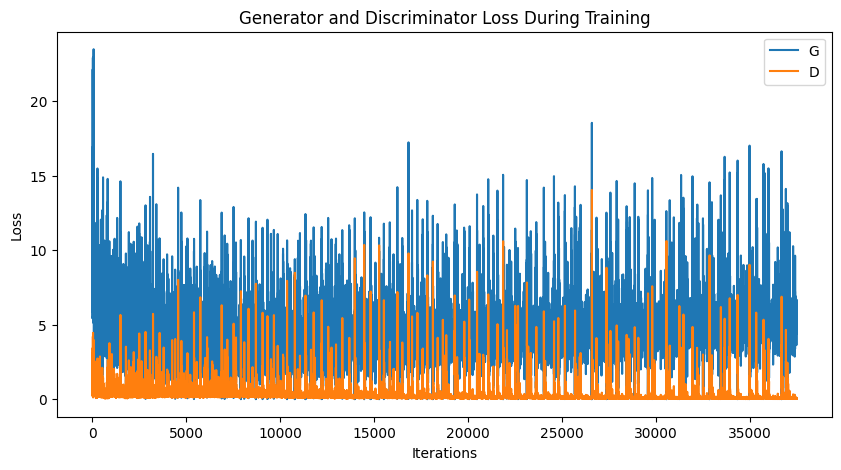

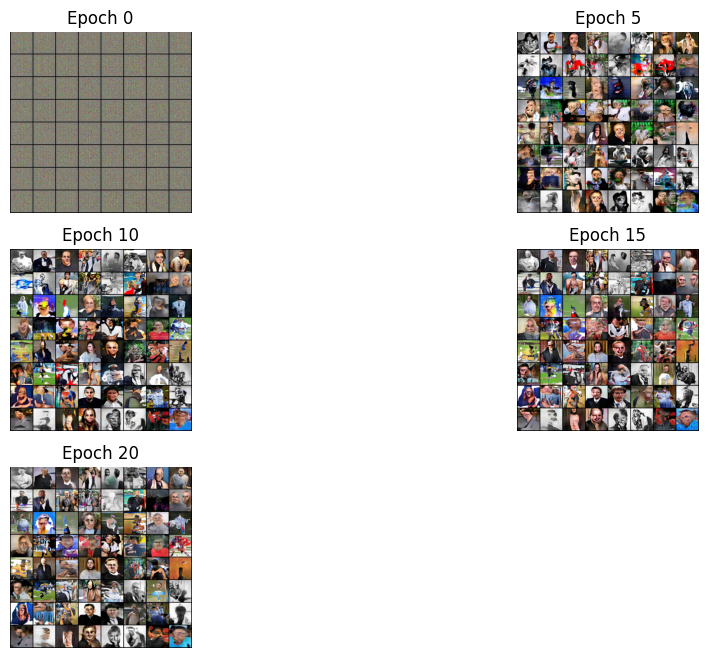

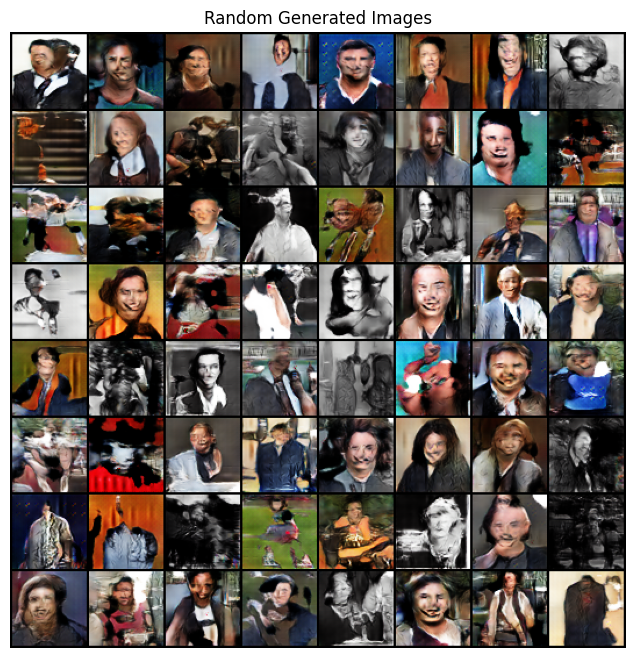

Training complete!


In [20]:
# Create instances and initialize weights
netG = Generator().to(device).apply(weights_init)
netD = Discriminator().to(device).apply(weights_init)

print("Generator:")
print(netG)
print("\nDiscriminator:")
print(netD)

# Setup optimizers
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# Loss function
criterion = nn.BCELoss()

# Create fixed noise for visualization
fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

# For tracking progress
real_label = 1.0
fake_label = 0.0
img_list = []
G_losses = []
D_losses = []

# Initialize trackers and lists for metrics
accuracy_tracker = AccuracyTracker()
fid_scores = []
is_scores = []
disc_accuracies = []
epochs_measured = []

# Training Loop
print("Starting Training...")
for epoch in range(num_epochs):
    for i, (data, _) in enumerate(train_loader):
        # Move data to device
        real_imgs = data.to(device)
        batch_size = real_imgs.size(0)
        
        # Create labels
        real_labels = torch.full((batch_size,), real_label, device=device)
        fake_labels = torch.full((batch_size,), fake_label, device=device)
        
        #############################
        # (1) Update Discriminator: maximize log(D(x)) + log(1 - D(G(z)))
        #############################
        netD.zero_grad()
        
        # Train with real images
        output = netD(real_imgs)
        accuracy_tracker.update_real(output)  # Add this line
        errD_real = criterion(output, real_labels)
        errD_real.backward()
        D_x = output.mean().item()
        
        # Train with fake images
        noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
        fake = netG(noise)
        output = netD(fake.detach())
        accuracy_tracker.update_fake(output)  # Add this line
        errD_fake = criterion(output, fake_labels)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        
        # Add gradients from all-real and all-fake batches
        errD = errD_real + errD_fake
        optimizerD.step()
        
        #############################
        # (2) Update Generator: maximize log(D(G(z)))
        #############################
        netG.zero_grad()
        output = netD(fake)  # D's output for fake images
        # Generator wants D to think these are real
        errG = criterion(output, real_labels)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()
        
        # Track losses
        if i % 50 == 0:
            print(f'[{epoch}/{num_epochs}][{i}/{len(train_loader)}] '
                  f'Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} '
                  f'D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f}/{D_G_z2:.4f}')
            
        G_losses.append(errG.item())
        D_losses.append(errD.item())
        
        # Save sample images every 100 batches
        if (epoch == 0 or epoch % 5 == 0) and i == 0:
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))
            
            # Save images
            img_name = f'fake_samples_epoch_{epoch:03d}.png'
            img_path = os.path.join('./results', img_name)
            vutils.save_image(fake, img_path, normalize=True)

    disc_metrics = accuracy_tracker.get_metrics()
    disc_accuracies.append(disc_metrics['overall_accuracy'])
    accuracy_tracker.reset()
    
    # Save models 
    if epoch % 5 == 0 or epoch == num_epochs - 1:
        torch.save({
            'epoch': epoch,
            'state_dict': netG.state_dict(),
            'optimizer': optimizerG.state_dict()
        }, f'./models/generator_epoch_{epoch}.pth')
        
        torch.save({
            'epoch': epoch,
            'state_dict': netD.state_dict(),
            'optimizer': optimizerD.state_dict()
        }, f'./models/discriminator_epoch_{epoch}.pth')
        
        print(f"Epoch {epoch}: Calculating FID and Inception Score...")
    
        # Save sample images for FID
        save_real_images(train_loader, num_images=500)  # Reduced for speed
        save_generated_images(netG, latent_dim, device, num_images=500)  # Reduced for speed
        
        # Calculate FID
        fid = calculate_fid(device)
        fid_scores.append(fid)
        
        # Calculate Inception Score
        is_mean, is_std = inception_score(netG, latent_dim, device, num_images=500)  # Reduced for speed
        is_scores.append(is_mean)
        
        epochs_measured.append(epoch)
        
        print(f"FID: {fid:.4f} | Inception Score: {is_mean:.4f}±{is_std:.4f}")
        print(f"Discriminator Accuracy: {disc_metrics['overall_accuracy']:.4f} " + 
            f"(Real: {disc_metrics['real_accuracy']:.4f}, Fake: {disc_metrics['fake_accuracy']:.4f})")

# Final visualization
# Plot losses
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.savefig('./results/loss_plot.png')
plt.show()

# Plot sample images from different epochs
plt.figure(figsize=(12, 8))
for i, img in enumerate(img_list):
    plt.subplot(3, len(img_list)//3 + 1, i+1)
    plt.axis("off")
    plt.title(f"Epoch {i*5}")
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
plt.savefig('./results/generation_progress.png')
plt.show()

# Generate and display random samples
with torch.no_grad():
    noise = torch.randn(64, latent_dim, 1, 1, device=device)
    fake = netG(noise).detach().cpu()
    
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Random Generated Images")
plt.imshow(np.transpose(vutils.make_grid(fake, padding=2, normalize=True), (1, 2, 0)))
plt.savefig('./results/final_samples.png')
plt.show()

print("Training complete!")

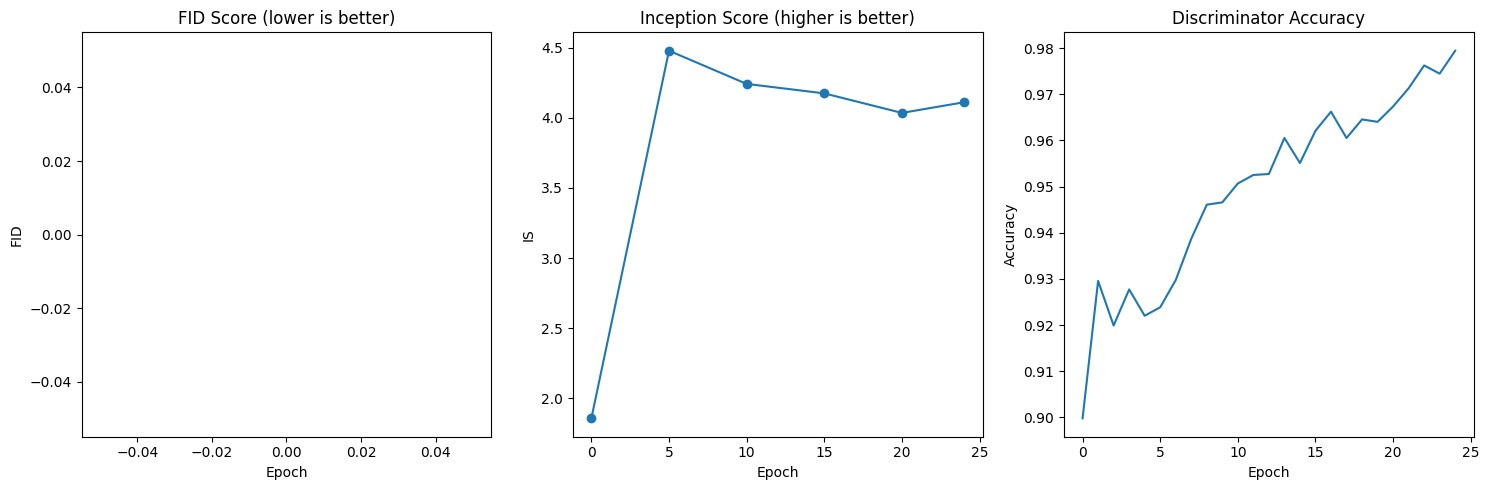

In [21]:
# Plot metrics
plt.figure(figsize=(15, 5))

# Plot FID scores
plt.subplot(1, 3, 1)
plt.plot(epochs_measured, fid_scores, marker='o')
plt.title('FID Score (lower is better)')
plt.xlabel('Epoch')
plt.ylabel('FID')

# Plot Inception scores
plt.subplot(1, 3, 2)
plt.plot(epochs_measured, is_scores, marker='o')
plt.title('Inception Score (higher is better)')
plt.xlabel('Epoch')
plt.ylabel('IS')

# Plot Discriminator accuracy
plt.subplot(1, 3, 3)
plt.plot(range(len(disc_accuracies)), disc_accuracies)
plt.title('Discriminator Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.savefig('metrics_plot.png')
plt.show()